import the data

In [1]:
import os
from torchvision import transforms
from PIL import Image
from pathlib import Path
import random
import matplotlib.pyplot as plt
from collections import Counter
from torchvision import transforms
import random

In [2]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Dataset'
healthy_path = os.path.join(dataset_path, 'Healthy')
autism_path = os.path.join(dataset_path, 'Autistic')
ndd_path = os.path.join(dataset_path, 'NDD')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
label_mapping = {
    'Healthy': 0,
    'Autistic': 1,
    'NDD': 2
}

data = []

for label_name, label in label_mapping.items():
    folder_path = os.path.join(dataset_path, label_name)
    for image_file in os.listdir(folder_path):
      data.append((os.path.join(folder_path, image_file), label))


from collections import Counter

labels = [label for _, label in data]

class_counts = Counter(labels)

print(f"Total images: {len(data)}")
for class_label, count in class_counts.items():
    print(f"Class {class_label}: {count} images")


Total images: 4410
Class 0: 1470 images
Class 1: 1470 images
Class 2: 1470 images


data augmentation

In [4]:
from collections import defaultdict
from tqdm import tqdm
import torch
from PIL import Image
from torchvision import transforms
import random

random.seed(42)

# Preprocessing function
def preprocess_image(image):
    """
    Preprocesses the image (resize, convert to RGB, tensor conversion, normalization).
    """
    image = image.convert("RGB")  # Convert to RGB
    image = image.resize((224, 224))  # Resize image to 224x224
    image = transforms.ToTensor()(image)  # Convert to tensor
    image = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image)  # Normalize
    return image

augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    #transforms.RandomRotation(degrees=15),
])

In [ ]:

augmented_data = []
class_counts = defaultdict(int)

for image_path, label in tqdm(data, desc="Processing images", unit="image"):
    image = Image.open(image_path)

    image_tensor = preprocess_image(image)

    augmented_image_tensor = augmentation_transforms(image_tensor)

    augmented_data.append((image_tensor, label))  # Preprocessed image
    augmented_data.append((augmented_image_tensor, label))  # Augmented image

    class_counts[label] += 2

# Save the augmented dataset
save_path = "/content/drive/MyDrive/augmented_dataset_pre.pt"
torch.save(augmented_data, save_path)

print("Dataset saved successfully to 'augmented_dataset_pre.pt'")

total_images = len(augmented_data)
print(f"Total images: {total_images}")
for label, count in class_counts.items():
    print(f"Class {label}: {count} images")


Processing images: 100%|██████████| 4410/4410 [00:37<00:00, 117.40image/s]


Dataset saved successfully to 'augmented_dataset_pre.pt'
Total images: 8820
Class 0: 2940 images
Class 1: 2940 images
Class 2: 2940 images


In [5]:
import torch
augmented_data = torch.load("/content/drive/MyDrive/augmented_dataset_pre.pt")

print(f"Loaded dataset size: {len(augmented_data)}")


<ipython-input-5-9ee4435b2d58>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  augmented_data = torch.load("/content/drive/MyDrive/augmented_dataset_pre.pt")


Loaded dataset size: 8820


data splitting 70% train

In [12]:
from sklearn.model_selection import train_test_split
import torch
from collections import defaultdict
import random

# Organize data by class
class_data = defaultdict(list)
for image, label in augmented_data:
    class_data[label].append((image, label))

train_data, val_data, test_data = [], [], []

# Define split ratios
train_ratio = 0.70  # 70% of total dataset
test_ratio = 0.15   # 15% of total dataset
val_ratio = 0.15  # 15% of total dataset

# Track class counts for each split
train_class_counts = defaultdict(int)
val_class_counts = defaultdict(int)
test_class_counts = defaultdict(int)

# Split each class separately
for label, images in class_data.items():
    train, temp = train_test_split(
        images, test_size=(test_ratio + val_ratio), random_state=42, stratify=[label] * len(images)
    )
    test, val = train_test_split(
        temp, test_size=0.50, random_state=42, stratify=[label] * len(temp)  # 50% to each
    )

    train_data.extend(train)
    val_data.extend(val)  # Unseen data
    test_data.extend(test)  # Unseen data

    # Count samples per class
    train_class_counts[label] = len(train)
    val_class_counts[label] = len(val)
    test_class_counts[label] = len(test)

# Shuffle the training data only
random.shuffle(train_data)

# Print class distribution
print("\nDataset Split Summary:")
print(f"Total Training Data: {len(train_data)} samples")
for label, count in train_class_counts.items():
    print(f"  Class {label}: {count} images")

print(f"\nTotal Validation Data: {len(val_data)} samples")
for label, count in val_class_counts.items():
    print(f"  Class {label}: {count} images")

print(f"\nTotal Test Data: {len(test_data)} samples")
for label, count in test_class_counts.items():
    print(f"  Class {label}: {count} images")

# Convert to TensorDataset
train_data = torch.utils.data.TensorDataset(
    torch.stack([item[0] for item in train_data]),
    torch.tensor([item[1] for item in train_data]))

val_data = torch.utils.data.TensorDataset(
    torch.stack([item[0] for item in val_data]),
    torch.tensor([item[1] for item in val_data]))

test_data = torch.utils.data.TensorDataset(
    torch.stack([item[0] for item in test_data]),
    torch.tensor([item[1] for item in test_data]))

# Create DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)



Dataset Split Summary:
Total Training Data: 6174 samples
  Class 0: 2058 images
  Class 1: 2058 images
  Class 2: 2058 images

Total Validation Data: 1323 samples
  Class 0: 441 images
  Class 1: 441 images
  Class 2: 441 images

Total Test Data: 1323 samples
  Class 0: 441 images
  Class 1: 441 images
  Class 2: 441 images


tiny

In [13]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import convnext_tiny

# Load the pre-trained ConvNeXt tiny model
model = convnext_tiny(pretrained=True)

num_classes = len(label_mapping)

#no dropout
#model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

#Dropout
model.classifier[2] = nn.Sequential(
    nn.Linear(model.classifier[2].in_features, 512),  # First FC layer
    nn.ReLU(),  # Activation function
    nn.Dropout(p=0.5),  # Dropout layer (50% dropout rate)
    nn.Linear(512, num_classes)  # Output layer
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


train

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()


        val_loss /= len(val_loader)
        val_acc = correct / total

        scheduler.step()

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10)


Epoch 1/10
Train Loss: 0.3752, Train Accuracy: 0.8413
Val Loss: 0.2144, Val Accuracy: 0.9138
Epoch 2/10
Train Loss: 0.1480, Train Accuracy: 0.9449
Val Loss: 0.1723, Val Accuracy: 0.9358
Epoch 3/10
Train Loss: 0.0603, Train Accuracy: 0.9804
Val Loss: 0.1637, Val Accuracy: 0.9410
Epoch 4/10
Train Loss: 0.0339, Train Accuracy: 0.9885
Val Loss: 0.5233, Val Accuracy: 0.8662
Epoch 5/10
Train Loss: 0.0371, Train Accuracy: 0.9862
Val Loss: 0.1326, Val Accuracy: 0.9607
Epoch 6/10
Train Loss: 0.0189, Train Accuracy: 0.9930
Val Loss: 0.1282, Val Accuracy: 0.9577
Epoch 7/10
Train Loss: 0.0273, Train Accuracy: 0.9916
Val Loss: 0.1537, Val Accuracy: 0.9539
Epoch 8/10
Train Loss: 0.0031, Train Accuracy: 0.9997
Val Loss: 0.1101, Val Accuracy: 0.9690
Epoch 9/10
Train Loss: 0.0023, Train Accuracy: 0.9994
Val Loss: 0.1065, Val Accuracy: 0.9728
Epoch 10/10
Train Loss: 0.0019, Train Accuracy: 0.9997
Val Loss: 0.1112, Val Accuracy: 0.9652


In [15]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {correct / total:.4f}")

test_model(model, test_loader)


Test Accuracy: 0.9766


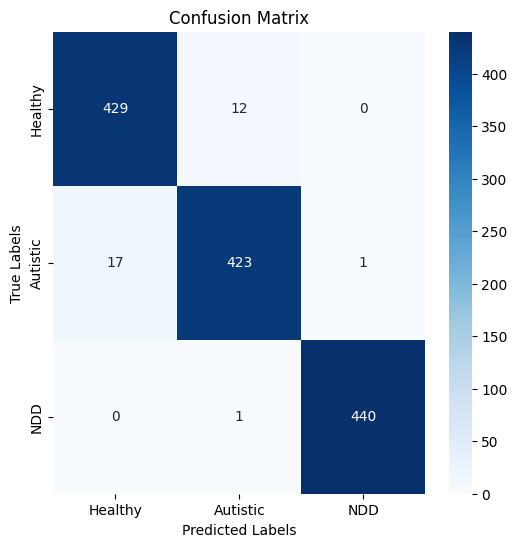

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.97       441
    Autistic       0.97      0.96      0.96       441
         NDD       1.00      1.00      1.00       441

    accuracy                           0.98      1323
   macro avg       0.98      0.98      0.98      1323
weighted avg       0.98      0.98      0.98      1323



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


true_labels = []
predicted_labels = []

# Evaluate on the test set
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(label_mapping.keys()), yticklabels=list(label_mapping.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report (Accuracy, Precision, Recall, F1-score)
report = classification_report(true_labels, predicted_labels, target_names=list(label_mapping.keys()))
print("Classification Report:")
print(report)


top 3 classes

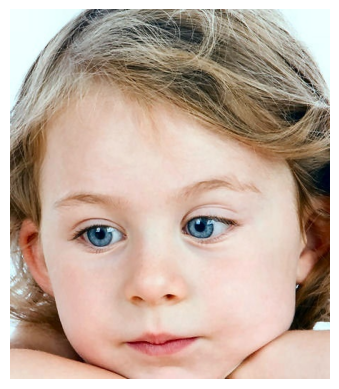

Top 3 Predictions:
Class: Autistic, Probability: 0.9998
Class: Healthy, Probability: 0.0001
Class: NDD, Probability: 0.0000


In [20]:
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import torch
import torch.nn.functional as F

# Preprocessing function (same as defined earlier)
def preprocess_image(image):
    """
    Preprocesses the image (resize, convert to RGB, tensor conversion, normalization).
    """
    image = image.convert("RGB")  # Convert to RGB
    image = image.resize((224, 224))  # Resize image to 224x224
    image = transforms.ToTensor()(image)  # Convert to tensor
    image = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image)  # Normalize
    return image

# Function to predict top 3 classes for a given image
def predict_top_3_classes(image_path, model, label_mapping, device):
    # Preprocess the image
    image = Image.open(image_path)

    # Display the image
    plt.imshow(image)
    plt.axis('off')  # Hide axes
    plt.show()

    # Preprocess image tensor
    image_tensor = preprocess_image(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Forward pass through the model
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)  # Apply softmax to get probabilities

    # Get the top 3 class indices and their probabilities
    top3_probabilities, top3_indices = torch.topk(probabilities, 3, dim=1)

    # Map the indices to class names
    top3_classes = [list(label_mapping.keys())[i] for i in top3_indices[0]]

    # Print the top 3 predictions with their probabilities
    print("Top 3 Predictions:")
    for i in range(3):
        print(f"Class: {top3_classes[i]}, Probability: {top3_probabilities[0][i].item():.4f}")

# Example usage:
image_path = '/content/drive/MyDrive/new-data-for-testing/Autism_test.jpg'  # Replace with your image path
predict_top_3_classes(image_path, model, label_mapping, device)


XAI

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


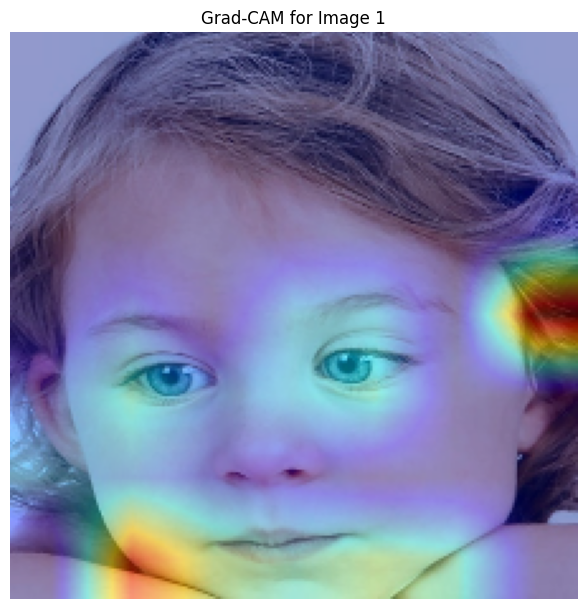

In [21]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.models import convnext_base
from PIL import Image
import cv2

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the model and ensure it's in evaluation mode
model = convnext_base(pretrained=True)
model.eval()
model = model.to(device)

# Global variables to store activations and gradients
gradients = None
activations = None

# Hook functions
def save_gradient(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]  # Capture the gradient of the output

def get_activations_hook(module, input, output):
    global activations
    activations = output

# Identify the last convolutional layer
last_conv_layer = model.features[-1]  # Adjust for the ConvNeXt architecture

# Register hooks to capture activations and gradients
hook = last_conv_layer.register_forward_hook(get_activations_hook)
hook_grad = last_conv_layer.register_full_backward_hook(save_gradient)

# Define the preprocessing function
def preprocess_image(image_path):
    image = Image.open(image_path)
    preprocess = transforms.Compose([
        transforms.Lambda(lambda img: img.convert('RGB')),  # Convert to RGB
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return preprocess(image).unsqueeze(0).to(device)



# Generating the Grad-CAM Heatmap
def generate_grad_cam(image_tensor, class_index):
    model.zero_grad()
    output = model(image_tensor)
    pred_class = output.argmax(dim=1)

    output[0, class_index].backward()

    global gradients
    global activations

    weights = gradients.mean(dim=[0, 2, 3], keepdim=True)  # Compute mean gradients
    grad_cam = torch.sum(weights * activations, dim=1).squeeze()
    grad_cam = F.relu(grad_cam).detach().cpu().numpy()
    grad_cam = np.maximum(grad_cam, 0)  # Ensure non-negative values
    grad_cam /= grad_cam.max()  # Normalize
    return grad_cam

# Overlay Grad-CAM on the original image
def display_grad_cam(image_path, grad_cam):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (224, 224))
    grad_cam = cv2.resize(grad_cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * grad_cam), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(image, 0.6, heatmap, 0.4, 0)

    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis('off')

# Example Usage for the first image
image_path_1 = '/content/drive/MyDrive/new-data-for-testing/Autism_test.jpg'  # Update with the correct image path
image_tensor_1 = preprocess_image(image_path_1)
class_index_1 = 1  # Change to the correct class index based on your dataset

# Generate Grad-CAM for the first image
grad_cam_1 = generate_grad_cam(image_tensor_1, class_index_1)

# Display both Grad-CAM results in a single figure
plt.figure(figsize=(12, 6))

# Display the first image with Grad-CAM
plt.subplot(1, 2, 1)
display_grad_cam(image_path_1, grad_cam_1)
plt.title("Grad-CAM for Image 1")

plt.tight_layout()
plt.show()